# Text Mining of YouTube Comments

## 1. Import Libraries

Library yang digunakan mencakup kebutuhan untuk data collection, text preprocessing, text representation, clustering, topic extraction, dan visualisasi.


In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Regular Expression
import re
import os

# String Processing
import string

# Emoji Removal
import emoji

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress Bar
from tqdm import tqdm

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Indonesian Stemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# YouTube Comment Scraping
from youtube_comment_downloader import YoutubeCommentDownloader

# Text Representation
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# Dimension Reduction
from sklearn.decomposition import PCA

# Topic Extraction
from bertopic import BERTopic

# Ignore Warning
import warnings
warnings.filterwarnings("ignore")

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/asyifaaaizza/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/asyifaaaizza/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/asyifaaaizza/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 2. Project Structure

Struktur folder digunakan untuk memisahkan dataset, model, visualisasi, dan hasil analisis agar proyek lebih terorganisir dan reproducible.


In [3]:
# ==========================================================
# CREATE PROJECT FOLDERS
# ==========================================================

import os

folders = [
    "data/question2",
    "models/question2",
    "output/question2/figures",
    "output/question2/results",
    "output/question2/reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Semua folder berhasil dibuat!")

Semua folder berhasil dibuat!


# 3. Data Collection

Komentar publik dari beberapa video YouTube mengenai **Artificial Intelligence dalam pendidikan di Indonesia** dikumpulkan menggunakan `youtube_comment_downloader`. Data mentah disimpan sebagai dataset CSV untuk tahap analisis berikutnya.


In [4]:
# ==========================================================
# LIST OF YOUTUBE VIDEOS
# ==========================================================

video_urls = [
    "https://www.youtube.com/watch?v=GK7VsV3DEwk",
    "https://www.youtube.com/watch?v=UUTaymXAtqU",
    "https://www.youtube.com/watch?v=KXKinQd1Gf8",
    "https://www.youtube.com/watch?v=Glvgjr-gPUQ",
    "https://www.youtube.com/watch?v=-xLRV9ebuMM",
    "https://www.youtube.com/watch?v=G30wThXVyAQ",
    "https://www.youtube.com/watch?v=dePCXPtZydE",
    "https://www.youtube.com/watch?v=aey4xkrz7zE&t=10s",
    "https://www.youtube.com/watch?v=djOlA8MOFSo",
    "https://www.youtube.com/watch?v=RYwFpsaeHDQ"
]

## Scraping YouTube Comments

Pada tahap ini dilakukan proses pengambilan komentar dari setiap video menggunakan library `youtube_comment_downloader`. Seluruh komentar yang berhasil diperoleh akan digabungkan menjadi satu dataset.

In [5]:
# ==========================================================
# SCRAPE YOUTUBE COMMENTS
# ==========================================================

downloader = YoutubeCommentDownloader()

all_comments = []

for idx, url in enumerate(video_urls, start=1):

    print(f"Processing Video {idx}...")

    try:

        comments = downloader.get_comments_from_url(url)

        count = 0

        for comment in comments:

            all_comments.append({

                "video_number": idx,
                "video_url": url,
                "author": comment.get("author"),
                "comment": comment.get("text"),
                "likes": comment.get("votes"),
                "published_time": comment.get("time")

            })

            count += 1

        print(f"Collected {count} comments.")

    except Exception as e:

        print(e)

print("-" * 50)
print(f"Total Comments : {len(all_comments)}")

Processing Video 1...
Collected 35 comments.
Processing Video 2...
Collected 206 comments.
Processing Video 3...
Collected 826 comments.
Processing Video 4...
Collected 1360 comments.
Processing Video 5...
Collected 194 comments.
Processing Video 6...
Collected 589 comments.
Processing Video 7...
Collected 413 comments.
Processing Video 8...
Collected 1257 comments.
Processing Video 9...
Collected 22 comments.
Processing Video 10...
Collected 2088 comments.
--------------------------------------------------
Total Comments : 6990


## Membuat Dataset

Seluruh komentar yang berhasil dikumpulkan kemudian dikonversi menjadi **DataFrame** menggunakan library **Pandas** sehingga lebih mudah untuk diproses pada tahap berikutnya.

In [6]:
# ==========================================================
# CREATE DATAFRAME
# ==========================================================

df = pd.DataFrame(all_comments)

print(df.shape)

df.head()

(6990, 6)


,video_number,video_url,author,comment,likes,published_time
0,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muasisulbais8088,"Perbanyak konten dengan para pakar bib, bosen ...",0,6 bulan yang lalu
1,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@RAFIUDINDINDUN,Semoga tidak menjadi Overwhelmed agar kedepann...,0,6 bulan yang lalu
2,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@W-Wabil,Hadir menyimak bib.🙏🏻,0,6 bulan yang lalu
3,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muhammadsyahfi5899,😶,0,6 bulan yang lalu
4,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@zawaafrida,konten seperti ini membuat kita umat islam yan...,0,6 bulan yang lalu


## Menyimpan Dataset

Dataset mentah hasil scraping disimpan dalam format **CSV** sehingga dapat digunakan kembali tanpa perlu melakukan proses scraping ulang.

In [7]:
# ==========================================================
# SAVE RAW DATASET
# ==========================================================

output_path = "data/question2/youtube_comments_raw.csv"

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Dataset saved to:\n{output_path}")

Dataset saved to:
data/question2/youtube_comments_raw.csv


# 4. Exploratory Data Analysis

EDA digunakan untuk memahami struktur dataset, missing values, duplicate data, statistik dasar, dan distribusi panjang komentar sebelum preprocessing.


In [8]:
# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("data/question2/youtube_comments_raw.csv")

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (6990, 6)


,video_number,video_url,author,comment,likes,published_time
0,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muasisulbais8088,"Perbanyak konten dengan para pakar bib, bosen ...",0,6 bulan yang lalu
1,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@RAFIUDINDINDUN,Semoga tidak menjadi Overwhelmed agar kedepann...,0,6 bulan yang lalu
2,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@W-Wabil,Hadir menyimak bib.🙏🏻,0,6 bulan yang lalu
3,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muhammadsyahfi5899,😶,0,6 bulan yang lalu
4,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@zawaafrida,konten seperti ini membuat kita umat islam yan...,0,6 bulan yang lalu


## Informasi Dataset

Tahap ini menampilkan informasi umum mengenai dataset, seperti jumlah observasi, jumlah variabel, tipe data masing-masing kolom, serta contoh data yang berhasil dikumpulkan.

In [9]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6990 entries, 0 to 6989
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   video_number    6990 non-null   int64
 1   video_url       6990 non-null   str  
 2   author          6990 non-null   str  
 3   comment         6990 non-null   str  
 4   likes           6990 non-null   str  
 5   published_time  6990 non-null   str  
dtypes: int64(1), str(5)
memory usage: 1.7 MB


## Missing Values

Pemeriksaan *missing values* dilakukan untuk mengetahui apakah terdapat data yang kosong pada setiap atribut sehingga dapat ditangani pada tahap preprocessing.

In [10]:
# ==========================================================
# MISSING VALUES
# ==========================================================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round(missing/len(df)*100,2)
})

missing_df

,Missing Values,Percentage (%)
video_number,0,0.0
video_url,0,0.0
author,0,0.0
comment,0,0.0
likes,0,0.0
published_time,0,0.0


## Duplicate Data

Pemeriksaan data duplikat dilakukan untuk mengetahui apakah terdapat komentar yang muncul lebih dari satu kali pada dataset.

In [11]:
# ==========================================================
# DUPLICATE DATA
# ==========================================================

duplicate = df.duplicated().sum()

print(f"Total Duplicate Data : {duplicate}")

Total Duplicate Data : 118


In [12]:
duplicate = df.drop_duplicates(inplace=True)

print(f"Total Duplicate Data : {duplicate}")

Total Duplicate Data : None


## Dataset Statistics

Beberapa statistik dasar dihitung untuk memberikan gambaran mengenai jumlah komentar, jumlah video yang digunakan, serta jumlah penulis komentar yang berhasil dikumpulkan.

In [13]:
# ==========================================================
# BASIC STATISTICS
# ==========================================================

print(f"Total Comments : {len(df)}")
print(f"Total Videos   : {df['video_number'].nunique()}")
print(f"Total Authors  : {df['author'].nunique()}")

Total Comments : 6872
Total Videos   : 10
Total Authors  : 5880


## Comment Length Distribution

Distribusi panjang komentar diamati untuk mengetahui karakteristik komentar yang dikumpulkan. Panjang komentar dihitung berdasarkan jumlah karakter pada setiap komentar.

In [14]:
# ==========================================================
# COMMENT LENGTH
# ==========================================================

df["comment_length"] = df["comment"].astype(str).apply(len)

df["comment_length"].describe()

count    6872.000000
mean      133.698341
std       241.902704
min         1.000000
25%        37.000000
50%        76.000000
75%       150.000000
max      9980.000000
Name: comment_length, dtype: float64

## Comment Length Visualization

Histogram digunakan untuk menggambarkan distribusi panjang komentar sehingga dapat diketahui apakah mayoritas komentar bersifat pendek, sedang, atau panjang.

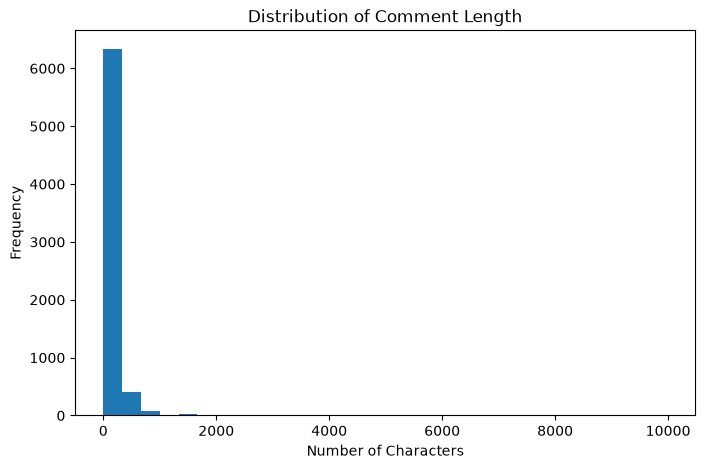

In [15]:
# ==========================================================
# COMMENT LENGTH DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(df["comment_length"], bins=30)

plt.title("Distribution of Comment Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

## Sample Comments

Beberapa komentar ditampilkan untuk memberikan gambaran mengenai isi dataset yang akan diproses pada tahap selanjutnya.

In [16]:
# ==========================================================
# SAMPLE COMMENTS
# ==========================================================

df[["comment"]].sample(5, random_state=42)

,comment
1807,"BANYAK ANAK-ANAK YANG SANGAT CERDAS, namun sul..."
6936,Jgn berharap terhadap pengurus/ pengelola Neg...
499,suara tiruan bisa dipake buat penipuan njir
2194,Bayar Tukin Dulu Prof
2303,KALO AI MENENTUKAN HUKUM ADA BAGUS NYA JUGA.. ...


# 5. Text Preprocessing

Komentar dibersihkan dan dinormalisasi melalui case folding, text cleaning, tokenization, stopword removal, dan stemming. Hasil akhirnya disimpan pada kolom **clean_comment**.


In [17]:
# ==========================================================
# COPY DATASET
# ==========================================================

df_clean = df.copy()

print(df_clean.shape)

df_clean.head()

(6872, 7)


,video_number,video_url,author,comment,likes,published_time,comment_length
0,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muasisulbais8088,"Perbanyak konten dengan para pakar bib, bosen ...",0,6 bulan yang lalu,128
1,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@RAFIUDINDINDUN,Semoga tidak menjadi Overwhelmed agar kedepann...,0,6 bulan yang lalu,82
2,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@W-Wabil,Hadir menyimak bib.🙏🏻,0,6 bulan yang lalu,21
3,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muhammadsyahfi5899,😶,0,6 bulan yang lalu,1
4,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@zawaafrida,konten seperti ini membuat kita umat islam yan...,0,6 bulan yang lalu,109


## 5.1 Case Folding

Case folding dilakukan untuk mengubah seluruh huruf menjadi huruf kecil (lowercase) sehingga kata dengan makna yang sama tidak dianggap sebagai kata yang berbeda akibat perbedaan kapitalisasi.

In [18]:
df_clean["case_folding"] = (
    df_clean["comment"]
    .astype(str)
    .str.lower()
)

## 5.2 Text Cleaning

Tahap *text cleaning* bertujuan menghilangkan karakter-karakter yang tidak memiliki kontribusi terhadap proses analisis teks. Proses ini meliputi penghapusan URL, emoji, angka, tanda baca, karakter khusus, serta spasi berlebih sehingga teks menjadi lebih bersih dan siap untuk diproses pada tahap berikutnya.

In [19]:
def clean_text(text):
    
    # Pastikan input berupa string
    text = str(text)

    # Remove URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove HTML entities
    text = re.sub(r'&\w+;', ' ', text)

    # Remove mention (@username)
    text = re.sub(r'@\w+', ' ', text)

    # Remove hashtag (#topic -> topic)
    text = re.sub(r'#', '', text)

    # Remove emoji
    text = emoji.replace_emoji(text, replace='')

    # Remove angka
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove karakter selain huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    return text

In [20]:
# ==========================================================
# APPLY TEXT CLEANING
# ==========================================================

df_clean["text_cleaning"] = df_clean["case_folding"].apply(clean_text)

df_clean[["comment", "text_cleaning"]].head()

,comment,text_cleaning
0,"Perbanyak konten dengan para pakar bib, bosen ...",perbanyak konten dengan para pakar bib bosen b...
1,Semoga tidak menjadi Overwhelmed agar kedepann...,semoga tidak menjadi overwhelmed agar kedepann...
2,Hadir menyimak bib.🙏🏻,hadir menyimak bib
3,😶,
4,konten seperti ini membuat kita umat islam yan...,konten seperti ini membuat kita umat islam yan...


In [21]:
# ==========================================================
# TEXT NORMALIZATION
# ==========================================================

normalization_dict = {
    "pake": "pakai",
    "ngga": "tidak",
    "gk": "tidak",
    "bgt": "banget",
    "dr": "dari",
    "utk": "untuk",
    "krn": "karena",
    "org": "orang",
    "sm": "sama",
    "dlm": "dalam",
    "tdk" : "tidak",
    "blm" : "belum",
    "dpt" : "dapat",
    "jg" : "juga",
    "trs" : "terus",
    "udh" : "sudah",
    "gmn" : "bagaimana",
    "knp" : "kenapa",
    "bgt" : "banget",
    "drpd" : "daripada"
}

def normalize_text(text):
    words = text.split()
    words = [normalization_dict.get(word, word) for word in words]
    return " ".join(words)

df_clean["normalized_text"] = df_clean["text_cleaning"].apply(normalize_text)

df_clean[["text_cleaning", "normalized_text"]].head()

,text_cleaning,normalized_text
0,perbanyak konten dengan para pakar bib bosen b...,perbanyak konten dengan para pakar bib bosen b...
1,semoga tidak menjadi overwhelmed agar kedepann...,semoga tidak menjadi overwhelmed agar kedepann...
2,hadir menyimak bib,hadir menyimak bib
3,,
4,konten seperti ini membuat kita umat islam yan...,konten seperti ini membuat kita umat islam yan...


## 5.3 Tokenization

Tokenization merupakan proses memecah setiap kalimat menjadi kumpulan kata (*tokens*). Tahap ini bertujuan agar setiap kata dapat diproses secara individual pada proses *stopword removal* dan *stemming*.

In [22]:
# ==========================================================
# TOKENIZATION
# ==========================================================

df_clean["tokens"] = df_clean["normalized_text"].apply(word_tokenize)

df_clean[["text_cleaning", "tokens"]].head()

,text_cleaning,tokens
0,perbanyak konten dengan para pakar bib bosen b...,"[perbanyak, konten, dengan, para, pakar, bib, ..."
1,semoga tidak menjadi overwhelmed agar kedepann...,"[semoga, tidak, menjadi, overwhelmed, agar, ke..."
2,hadir menyimak bib,"[hadir, menyimak, bib]"
3,,[]
4,konten seperti ini membuat kita umat islam yan...,"[konten, seperti, ini, membuat, kita, umat, is..."


## 5.4 Stopword Removal

Tahap *stopword removal* bertujuan menghapus kata-kata umum (*stopwords*) yang memiliki frekuensi tinggi namun tidak memberikan informasi yang signifikan terhadap proses analisis. Selain menggunakan daftar *stopwords* Bahasa Indonesia dari NLTK, penelitian ini juga menambahkan beberapa *custom stopwords* yang umum digunakan pada komentar YouTube, seperti kata-kata informal dan kata pengisi percakapan.

Hasil dari tahap ini berupa daftar token yang hanya berisi kata-kata penting (*content words*) sehingga dapat meningkatkan kualitas representasi teks pada proses clustering dan topic extraction.

In [23]:
# ==========================================================
# STOPWORDS
# ==========================================================

# Stopwords bawaan NLTK
stop_words = set(stopwords.words("indonesian"))

# Tambahan stopwords untuk komentar YouTube
additional_stopwords = {

    # ======================
    # Slang
    # ======================
    "yg","ya","iya","yah","aja","ajaa","nih","sih","deh","dong",
    "lah","kan","kok","mah","loh","lho","lahh","nah","tuh",

    # ======================
    # Negation / Informal
    # ======================
    "ga","gak","nggak","enggak","tdk","tak","udah","udahh",
    "udahhh","kalo","kalau",

    # ======================
    # Pronouns
    # ======================
    "gw","gua","gue","aku","sy","saya","kami","kita",
    "lu","loe","elo","anda","kamu","dia","beliau","mereka",

    # ======================
    # Filler Words
    # ======================
    "wkwk","wk","wkwkwk","hehe","hehehe",
    "haha","hahaha","hoho","lol","btw",

    # ======================
    # Sapaan
    # ======================
    "bang","bg","bro","bruh","bos",
    "mas","mba","mbak",
    "pak","bu","bapak","ibu",
    "prof",

    # ======================
    # Youtube Words
    # ======================
    "subscribe","sub","like","share",
    "youtube","yt","channel",

    # ======================
    # Nama Narasumber
    # ======================
    "davyn",
    "helmy",
    "stella",

    # ======================
    # Kata Umum
    # ======================
    "dll","dsb","nih","nya","nyaa",

    # ======================
    # Singkatan
    # ======================
    "utk","dr","krn","jd","tp","dgn",

    # ======================
    # Noise
    # ======================
    "ok","oke","okay","okey",
    "amin","aamiin","amiin",
    "wow","mantap"
}

# Gabungkan
stop_words = stop_words.union(additional_stopwords)

print(f"Total stopwords: {len(stop_words)}")

Total stopwords: 836


In [24]:
# ==========================================================
# STOPWORD REMOVAL FUNCTION
# ==========================================================

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

In [25]:
# ==========================================================
# APPLY STOPWORD REMOVAL
# ==========================================================

df_clean["stopwords_removed"] = df_clean["tokens"].apply(remove_stopwords)

df_clean[
    [
        "tokens",
        "stopwords_removed"
    ]
].head()                                       

,tokens,stopwords_removed
0,"[perbanyak, konten, dengan, para, pakar, bib, ...","[perbanyak, konten, pakar, bib, bosen, banget,..."
1,"[semoga, tidak, menjadi, overwhelmed, agar, ke...","[semoga, overwhelmed, kedepannya, pribadi, wis..."
2,"[hadir, menyimak, bib]","[hadir, menyimak, bib]"
3,[],[]
4,"[konten, seperti, ini, membuat, kita, umat, is...","[konten, umat, islam, tulen, tradisi, kesantri..."


## 5.5 Stemming

Tahap *stemming* bertujuan mengubah setiap kata menjadi bentuk dasarnya (*root word*). Proses ini dilakukan menggunakan library **Sastrawi** yang dirancang khusus untuk Bahasa Indonesia.

Dengan melakukan stemming, variasi kata yang memiliki makna sama, seperti *membantu*, *dibantu*, dan *membantukan*, akan direduksi menjadi bentuk dasar yang sama sehingga mampu meningkatkan kualitas representasi teks pada proses clustering maupun topic extraction.

In [26]:
# ==========================================================
# CREATE STEMMER
# ==========================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [27]:
# ==========================================================
# STEMMING FUNCTION
# ==========================================================

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

In [28]:
# ==========================================================
# STEMMING FUNCTION
# ==========================================================

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

In [29]:
# ==========================================================
# APPLY STEMMING
# ==========================================================

df_clean["stemmed"] = df_clean["stopwords_removed"].apply(stemming)

df_clean[
    [
        "stopwords_removed",
        "stemmed"
    ]
].head()

,stopwords_removed,stemmed
0,"[perbanyak, konten, pakar, bib, bosen, banget,...","[banyak, konten, pakar, bib, bosen, banget, li..."
1,"[semoga, overwhelmed, kedepannya, pribadi, wis...","[moga, overwhelmed, depan, pribadi, wisdom]"
2,"[hadir, menyimak, bib]","[hadir, simak, bib]"
3,[],[]
4,"[konten, umat, islam, tulen, tradisi, kesantri...","[konten, umat, islam, tulen, tradisi, santri, ..."


## 5.6 Final Preprocessed Text

Setelah seluruh tahapan preprocessing selesai dilakukan, daftar token hasil stemming digabungkan kembali menjadi sebuah kalimat sehingga diperoleh kolom **clean_comment**.

Kolom ini merupakan hasil akhir preprocessing dan akan digunakan sebagai input pada proses representasi teks menggunakan **TF-IDF** dan **Sentence Transformer**.

In [30]:
 # ==========================================================
# CREATE FINAL CLEAN TEXT
# ==========================================================

df_clean["clean_comment"] = df_clean["stemmed"].apply(
    lambda words: " ".join(words)
)

df_clean[
    [
        "comment",
        "clean_comment"
    ]
].head()

,comment,clean_comment
0,"Perbanyak konten dengan para pakar bib, bosen ...",banyak konten pakar bib bosen banget liat neti...
1,Semoga tidak menjadi Overwhelmed agar kedepann...,moga overwhelmed depan pribadi wisdom
2,Hadir menyimak bib.🙏🏻,hadir simak bib
3,😶,
4,konten seperti ini membuat kita umat islam yan...,konten umat islam tulen tradisi santri open mi...


## Before and After Preprocessing

Tabel berikut memperlihatkan perbedaan komentar sebelum dilakukan preprocessing dan setelah seluruh tahapan preprocessing selesai dilakukan.

In [31]:
# ==========================================================
# BEFORE VS AFTER PREPROCESSING
# ==========================================================

comparison = df_clean[
    [
        "comment",
        "clean_comment"
    ]
].sample(10, random_state=42)

comparison

,comment,clean_comment
1807,"BANYAK ANAK-ANAK YANG SANGAT CERDAS, namun sul...",anakanak cerdas sulit angkat negeri ras
6936,Jgn berharap terhadap pengurus/ pengelola Neg...,jgn harap urus kelola negara pimpin hasil prod...
499,suara tiruan bisa dipake buat penipuan njir,suara tiru dipake tipu njir
2194,Bayar Tukin Dulu Prof,bayar tukin
2303,KALO AI MENENTUKAN HUKUM ADA BAGUS NYA JUGA.. ...,ai tentu hukum bagus intervensi suap
4728,"Pendapat saya,masalahlah yang membuat mereka b...",dapat sayamasalahlah kembang majumenyelesaikan...
5735,Pemuda Generasi Indonesia kedepan,pemuda generasi indonesia depan
591,"Wouw... Yg q rasain, yg komen di channel ini k...",wouw q rasain komen banyak orang hebat
6651,Kalo ada 1000 anak muda spt ini...maka akan ad...,anak muda spt inimaka teriak jajah asing aseng
2215,Kelas diskusi nya,kelas diskusi


## Save Preprocessed Dataset

Dataset hasil preprocessing disimpan dalam format CSV sehingga dapat langsung digunakan pada tahap representasi teks dan pemodelan unsupervised learning.

In [32]:
# ==========================================================
# SAVE PREPROCESSED DATASET
# ==========================================================

output_path = "data/question2/youtube_comments_clean.csv"

df_clean.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Preprocessed dataset saved to:\n{output_path}")

Preprocessed dataset saved to:
data/question2/youtube_comments_clean.csv


# 6. Text Representation

Teks direpresentasikan menggunakan dua pendekatan: **TF-IDF** dan **Sentence Transformer Embedding**. Keduanya digunakan sebagai input untuk proses clustering.


## 6.1 TF-IDF Representation

TF-IDF merupakan metode representasi teks berbasis frekuensi kata yang memberikan bobot lebih tinggi pada kata-kata yang sering muncul dalam suatu dokumen namun jarang muncul pada dokumen lainnya.

In [33]:
# ==========================================================
# TF-IDF REPRESENTATION
# ==========================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_tfidf = tfidf.fit_transform(df_clean["clean_comment"])

print("TF-IDF Shape :", X_tfidf.shape)

TF-IDF Shape : (6872, 5000)


In [34]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aamin' 'abad' 'abai' 'abang' 'abdi' 'abis' 'about' 'academy' 'acak'
 'acara' 'access' 'account' 'accounting' 'action' 'actually' 'acu' 'ad'
 'ada' 'ada ai' 'ada guru' 'adab' 'adab manusia' 'adapt' 'adaptasi'
 'adaptasi ai' 'adaptasi teknologi' 'adaptif' 'ade' 'adek' 'adhi']


In [35]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=feature_names
)

tfidf_df.head()

,aamin,abad,abai,abang,abdi,abis,about,academy,acak,acara,...,youre,youtuber,yra,yuk,yuval,zaman,zaman ai,zero,zona,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6.2 Sentence Transformer Representation

Selain menggunakan TF-IDF, penelitian ini juga menggunakan representasi berbasis **Sentence Transformer**. Berbeda dengan TF-IDF yang hanya mempertimbangkan frekuensi kata, Sentence Transformer menghasilkan representasi vektor yang mampu menangkap makna semantik dari suatu kalimat.

Model yang digunakan adalah **paraphrase-multilingual-MiniLM-L12-v2** karena mendukung berbagai bahasa termasuk Bahasa Indonesia serta memiliki performa yang baik untuk tugas clustering dokumen pendek seperti komentar YouTube.

In [36]:
# ==========================================================
# LOAD SENTENCE TRANSFORMER
# ==========================================================

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [37]:
# ==========================================================
# CREATE SENTENCE EMBEDDINGS
# ==========================================================

X_embedding = embedding_model.encode(
    df_clean["clean_comment"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding Shape :", X_embedding.shape)

Batches:   0%|          | 0/215 [00:00<?, ?it/s]

Embedding Shape : (6872, 384)


In [38]:
embedding_df = pd.DataFrame(X_embedding)

embedding_df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.181370,-0.177636,-0.200129,-0.045818,-0.019299,-0.065332,-0.077010,0.006592,0.115605,0.077908,...,0.036918,-0.081928,0.017370,-0.063871,-0.008461,0.103262,0.211091,0.019518,0.132412,-0.092035
1,0.233393,0.121978,-0.317641,0.149701,0.107531,-0.066703,0.290843,-0.040092,0.162754,-0.061688,...,0.118029,-0.005453,0.252143,0.486644,-0.556521,0.027867,0.290443,0.163878,-0.075365,0.148140
2,0.044649,0.168623,0.025131,-0.089718,-0.089095,0.003940,0.284760,0.037717,-0.075859,-0.009812,...,0.165359,-0.098752,-0.047579,-0.142872,-0.219768,0.107226,0.138320,-0.032237,-0.012531,0.059086
3,0.226917,0.081784,0.023543,-0.030236,0.011576,-0.084300,0.442815,0.180795,0.104702,0.053833,...,0.166592,-0.048261,0.042300,-0.001559,-0.166649,0.216904,0.185915,-0.099829,-0.031076,0.074184
4,0.263830,0.422616,-0.450953,0.222553,-0.193343,0.134843,-0.049624,-0.394162,0.086292,0.305103,...,-0.352690,-0.093367,0.187297,-0.069490,-0.024799,0.350025,0.131562,-0.024504,-0.060889,0.141744


## 6.3 Perbandingan Text Representation

Penelitian ini menggunakan dua pendekatan representasi teks yang memiliki karakteristik berbeda.

- **TF-IDF** merepresentasikan teks berdasarkan frekuensi kemunculan kata sehingga menghasilkan representasi yang bersifat sparse dan berdimensi tinggi.

- **Sentence Transformer** menghasilkan representasi berbasis semantic embedding sehingga mampu menangkap hubungan makna antar kalimat dan menghasilkan representasi yang lebih padat (dense).

Kedua representasi tersebut selanjutnya digunakan sebagai input pada proses clustering sehingga dapat dibandingkan kualitas cluster yang dihasilkan menggunakan Silhouette Score.

In [39]:
# ==========================================================
# COMPARISON OF TEXT REPRESENTATION
# ==========================================================

comparison_representation = pd.DataFrame({
    "Representation": [
        "TF-IDF",
        "Sentence Transformer"
    ],
    "Dimension": [
        X_tfidf.shape[1],
        X_embedding.shape[1]
    ],
    "Output Shape": [
        str(X_tfidf.shape),
        str(X_embedding.shape)
    ],
    "Representation Type": [
        "Sparse Vector",
        "Dense Semantic Embedding"
    ]
})

comparison_representation

,Representation,Dimension,Output Shape,Representation Type
0,TF-IDF,5000,"(6872, 5000)",Sparse Vector
1,Sentence Transformer,384,"(6872, 384)",Dense Semantic Embedding


# 7. Clustering

Komentar dikelompokkan menggunakan **K-Means Clustering**. Nilai `k` diuji dari 2 hingga 6 dan kualitas cluster dibandingkan menggunakan **Silhouette Score** pada kedua representasi teks.


## 7.1 K-Means Clustering menggunakan TF-IDF

Representasi TF-IDF digunakan sebagai input bagi algoritma K-Means. Proses clustering dilakukan menggunakan beberapa nilai jumlah cluster (*k*) untuk menentukan konfigurasi terbaik berdasarkan Silhouette Score.

In [40]:
# ==========================================================
# TF-IDF CLUSTERING
# ==========================================================

k_values = [2,3,4,5,6]

tfidf_scores = []

for k in k_values:

    print(f"Processing k = {k}")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_tfidf)

    score = silhouette_score(
        X_tfidf,
        labels
    )

    tfidf_scores.append(score)

    print(f"Silhouette Score : {score:.4f}")
    print("-"*40)

Processing k = 2
Silhouette Score : 0.0195
----------------------------------------
Processing k = 3
Silhouette Score : 0.0228
----------------------------------------
Processing k = 4
Silhouette Score : 0.0229
----------------------------------------
Processing k = 5
Silhouette Score : 0.0197
----------------------------------------
Processing k = 6
Silhouette Score : 0.0233
----------------------------------------


In [41]:
tfidf_result = pd.DataFrame({

    "k":k_values,

    "Silhouette Score":tfidf_scores

})

tfidf_result

,k,Silhouette Score
0,2,0.019539
1,3,0.022816
2,4,0.022861
3,5,0.019654
4,6,0.023285


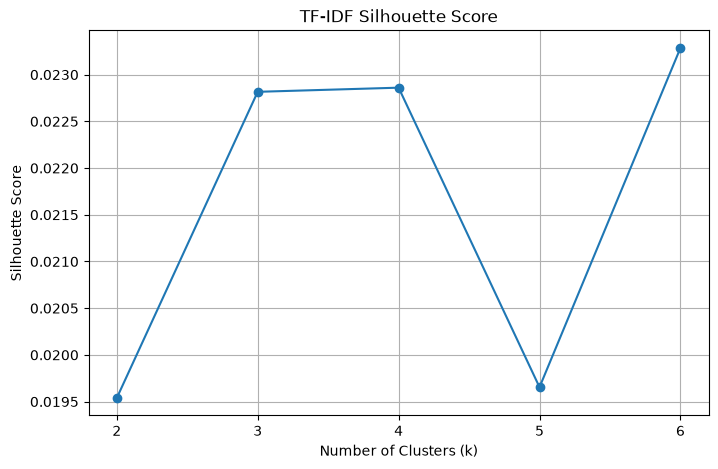

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    tfidf_result["k"],
    tfidf_result["Silhouette Score"],
    marker="o"
)

plt.xticks(k_values)

plt.grid(True)

plt.title("TF-IDF Silhouette Score")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.show()

## 7.2 K-Means Clustering menggunakan Sentence Transformer

Representasi semantic embedding dari Sentence Transformer selanjutnya digunakan sebagai input K-Means. Proses yang sama dilakukan dengan beberapa nilai jumlah cluster sehingga dapat dibandingkan dengan hasil representasi TF-IDF.

In [43]:
# ==========================================================
# SENTENCE EMBEDDING CLUSTERING
# ==========================================================

embedding_scores = []

for k in k_values:

    print(f"Processing k = {k}")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_embedding)

    score = silhouette_score(
        X_embedding,
        labels
    )

    embedding_scores.append(score)

    print(f"Silhouette Score : {score:.4f}")
    print("-"*40)

Processing k = 2
Silhouette Score : 0.0723
----------------------------------------
Processing k = 3
Silhouette Score : 0.0847
----------------------------------------
Processing k = 4
Silhouette Score : 0.0732
----------------------------------------
Processing k = 5
Silhouette Score : 0.0712
----------------------------------------
Processing k = 6
Silhouette Score : 0.0718
----------------------------------------


In [44]:
embedding_result = pd.DataFrame({

    "k":k_values,

    "Silhouette Score":embedding_scores

})

embedding_result

,k,Silhouette Score
0,2,0.072324
1,3,0.084693
2,4,0.073201
3,5,0.071205
4,6,0.071833


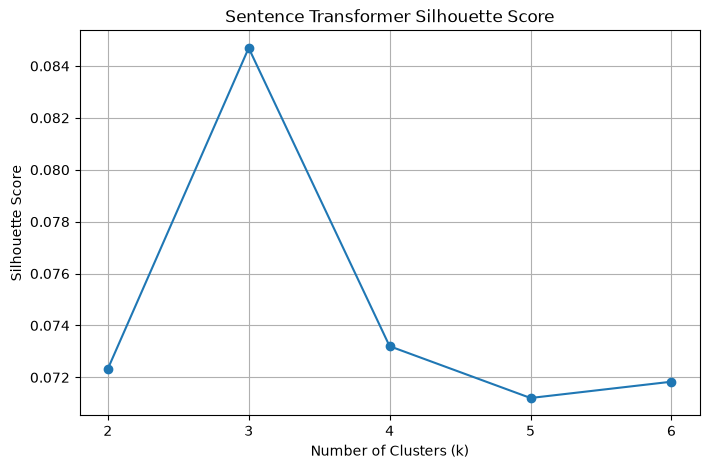

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    embedding_result["k"],
    embedding_result["Silhouette Score"],
    marker="o"
)

plt.xticks(k_values)

plt.grid(True)

plt.title("Sentence Transformer Silhouette Score")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.show()

## 7.3 Perbandingan Hasil Clustering

Nilai Silhouette Score dari kedua pendekatan representasi teks dibandingkan untuk menentukan kombinasi representasi teks dan jumlah cluster (*k*) yang memberikan kualitas clustering terbaik.

In [46]:
comparison_cluster = pd.DataFrame({

    "k":k_values,

    "TF-IDF":tfidf_scores,

    "Sentence Transformer":embedding_scores

})

comparison_cluster

,k,TF-IDF,Sentence Transformer
0,2,0.019539,0.072324
1,3,0.022816,0.084693
2,4,0.022861,0.073201
3,5,0.019654,0.071205
4,6,0.023285,0.071833


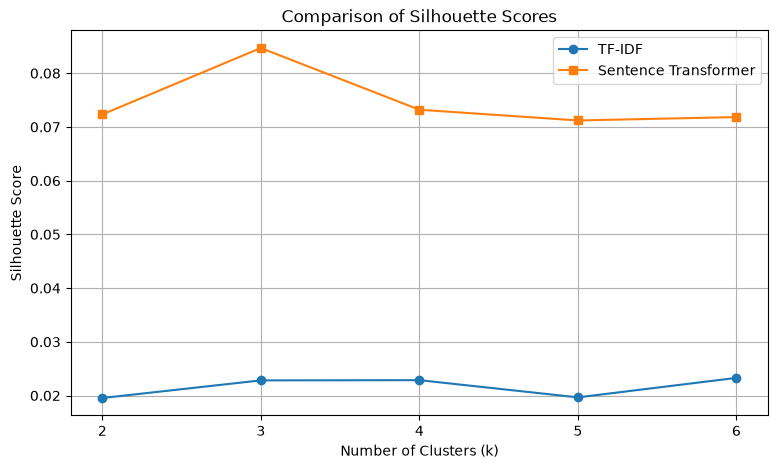

In [47]:
plt.figure(figsize=(9,5))

plt.plot(
    comparison_cluster["k"],
    comparison_cluster["TF-IDF"],
    marker="o",
    label="TF-IDF"
)

plt.plot(
    comparison_cluster["k"],
    comparison_cluster["Sentence Transformer"],
    marker="s",
    label="Sentence Transformer"
)

plt.xticks(k_values)

plt.grid(True)

plt.legend()

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.title("Comparison of Silhouette Scores")

plt.show()

### Clustering Result

Berdasarkan Silhouette Score, konfigurasi terbaik menggunakan **Sentence Transformer** dengan **k = 3** dan Silhouette Score **0.0847**.


## 7.4 Pemilihan Model Clustering Terbaik

Berdasarkan hasil evaluasi menggunakan Silhouette Score, dipilih konfigurasi clustering dengan nilai Silhouette Score tertinggi.

Model terbaik selanjutnya digunakan pada proses **Persona Analysis** sehingga interpretasi cluster dilakukan berdasarkan konfigurasi yang paling optimal.

In [48]:
# ==========================================================
# SELECT BEST MODEL
# ==========================================================

best_k = 3

best_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_clean["cluster"] = best_model.fit_predict(X_embedding)

print(df_clean["cluster"].value_counts())

df_clean.head()

cluster
1    3957
0    1992
2     923
Name: count, dtype: int64


,video_number,video_url,author,comment,likes,published_time,comment_length,case_folding,text_cleaning,normalized_text,tokens,stopwords_removed,stemmed,clean_comment,cluster
0,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muasisulbais8088,"Perbanyak konten dengan para pakar bib, bosen ...",0,6 bulan yang lalu,128,"perbanyak konten dengan para pakar bib, bosen ...",perbanyak konten dengan para pakar bib bosen b...,perbanyak konten dengan para pakar bib bosen b...,"[perbanyak, konten, dengan, para, pakar, bib, ...","[perbanyak, konten, pakar, bib, bosen, banget,...","[banyak, konten, pakar, bib, bosen, banget, li...",banyak konten pakar bib bosen banget liat neti...,1
1,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@RAFIUDINDINDUN,Semoga tidak menjadi Overwhelmed agar kedepann...,0,6 bulan yang lalu,82,semoga tidak menjadi overwhelmed agar kedepann...,semoga tidak menjadi overwhelmed agar kedepann...,semoga tidak menjadi overwhelmed agar kedepann...,"[semoga, tidak, menjadi, overwhelmed, agar, ke...","[semoga, overwhelmed, kedepannya, pribadi, wis...","[moga, overwhelmed, depan, pribadi, wisdom]",moga overwhelmed depan pribadi wisdom,1
2,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@W-Wabil,Hadir menyimak bib.🙏🏻,0,6 bulan yang lalu,21,hadir menyimak bib.🙏🏻,hadir menyimak bib,hadir menyimak bib,"[hadir, menyimak, bib]","[hadir, menyimak, bib]","[hadir, simak, bib]",hadir simak bib,0
3,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@muhammadsyahfi5899,😶,0,6 bulan yang lalu,1,😶,,,[],[],[],,0
4,1,https://www.youtube.com/watch?v=GK7VsV3DEwk,@zawaafrida,konten seperti ini membuat kita umat islam yan...,0,6 bulan yang lalu,109,konten seperti ini membuat kita umat islam yan...,konten seperti ini membuat kita umat islam yan...,konten seperti ini membuat kita umat islam yan...,"[konten, seperti, ini, membuat, kita, umat, is...","[konten, umat, islam, tulen, tradisi, kesantri...","[konten, umat, islam, tulen, tradisi, santri, ...",konten umat islam tulen tradisi santri open mi...,2


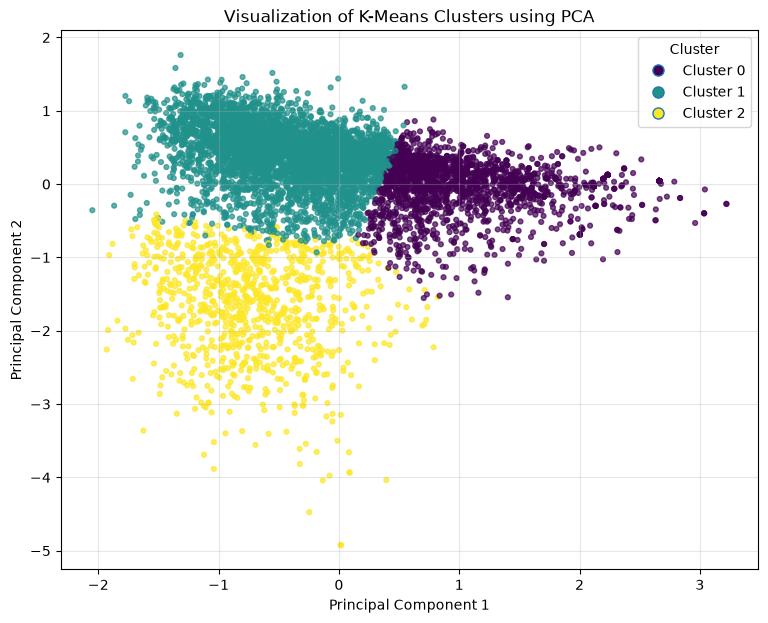

In [49]:
from matplotlib.lines import Line2D

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_embedding)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clean["cluster"],
    cmap="viridis",
    s=12,
    alpha=0.7
)

plt.title("Visualization of K-Means Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Legend otomatis berdasarkan jumlah cluster
handles = []
for c in sorted(df_clean["cluster"].unique()):
    handles.append(
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            label=f"Cluster {c}",
            markerfacecolor=scatter.cmap(scatter.norm(c)),
            markersize=8
        )
    )

plt.legend(handles=handles, title="Cluster")
plt.grid(alpha=0.3)

plt.show()

In [50]:
# ==========================================================
# SAVE CLUSTER RESULT
# ==========================================================

df_clean.to_csv(
    "output/question2/results/clustering_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Cluster result saved.")

Cluster result saved.


# 8. Persona Analysis

Karakteristik setiap cluster diinterpretasikan berdasarkan distribusi data, top keywords, word cloud, dan contoh komentar.


## Distribusi Cluster

Tahap ini menampilkan jumlah komentar yang termasuk ke dalam masing-masing cluster hasil proses clustering.

In [51]:
# ==========================================================
# CLUSTER DISTRIBUTION
# ==========================================================

cluster_distribution = (
    df_clean["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_distribution.columns = ["Cluster", "Total Comments"]

cluster_distribution

,Cluster,Total Comments
0,0,1992
1,1,3957
2,2,923


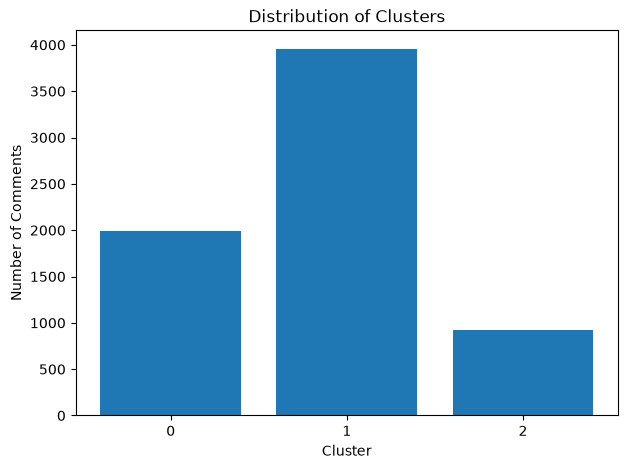

In [52]:
plt.figure(figsize=(7,5))

plt.bar(
    cluster_distribution["Cluster"].astype(str),
    cluster_distribution["Total Comments"]
)

plt.title("Distribution of Clusters")

plt.xlabel("Cluster")

plt.ylabel("Number of Comments")

plt.show()

In [53]:
# ==========================================================
# TOP KEYWORDS
# ==========================================================

from collections import Counter

for cluster in sorted(df_clean["cluster"].unique()):

    print("="*70)
    print(f"CLUSTER {cluster}")
    print("="*70)

    words = []

    subset = df_clean[df_clean["cluster"] == cluster]

    for tokens in subset["stemmed"]:
        words.extend(tokens)

    common_words = Counter(words).most_common(20)

    print(common_words)
    print()

CLUSTER 0
[('ai', 216), ('keren', 138), ('banget', 79), ('anak', 65), ('kasih', 45), ('ajar', 44), ('hebat', 43), ('terima', 40), ('you', 39), ('bangga', 33), ('pakai', 32), ('moga', 31), ('muda', 31), ('orang', 27), ('bagus', 24), ('n', 24), ('gin', 23), ('daging', 23), ('good', 23), ('tuju', 22)]

CLUSTER 1
[('ai', 2524), ('orang', 680), ('manusia', 626), ('ajar', 584), ('pakai', 465), ('kerja', 442), ('anak', 415), ('teknologi', 281), ('guru', 276), ('didik', 251), ('bikin', 244), ('ganti', 239), ('kembang', 227), ('negara', 223), ('banget', 222), ('hasil', 217), ('claude', 213), ('data', 203), ('pikir', 198), ('muda', 197)]

CLUSTER 2
[('indonesia', 1000), ('anak', 315), ('orang', 237), ('ai', 211), ('negara', 188), ('didik', 180), ('muda', 170), ('moga', 151), ('maju', 143), ('bangsa', 127), ('perintah', 73), ('bahasa', 72), ('ajar', 71), ('cerdas', 65), ('guru', 63), ('generasi', 62), ('pikir', 57), ('ilmu', 56), ('dunia', 55), ('keren', 53)]



## Visualisasi Word Cloud

Word Cloud digunakan untuk memvisualisasikan kata-kata yang paling dominan pada setiap cluster sehingga karakteristik masing-masing cluster dapat diamati secara lebih intuitif.

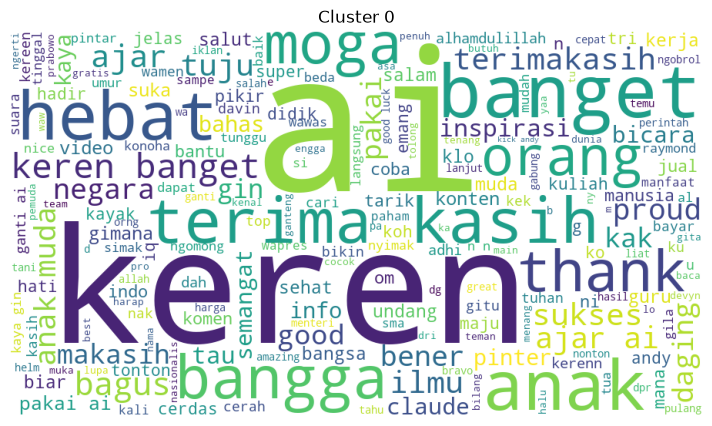

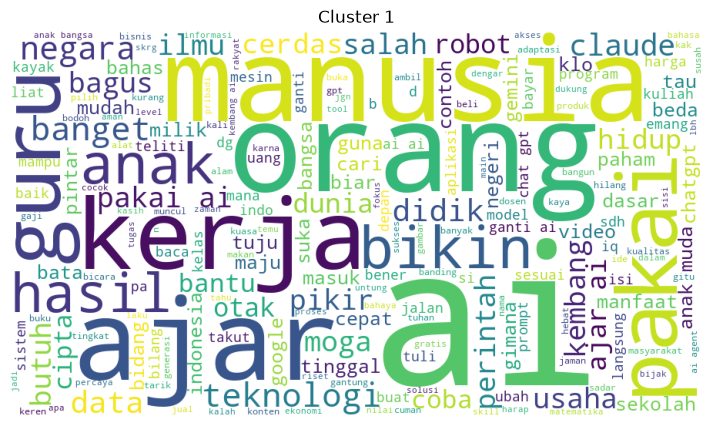

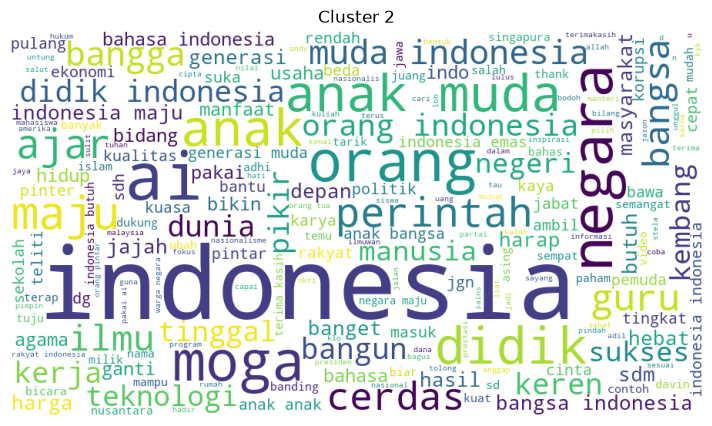

In [54]:
# ==========================================================
# WORD CLOUD FOR EACH CLUSTER
# ==========================================================

from wordcloud import WordCloud

for cluster in sorted(df_clean["cluster"].unique()):

    subset = df_clean[df_clean["cluster"] == cluster]

    text = " ".join(subset["clean_comment"])

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))

    plt.imshow(wc)

    plt.axis("off")

    plt.title(f"Cluster {cluster}")

    plt.show()

In [55]:
# ==========================================================
# SAMPLE COMMENTS FROM EACH CLUSTER
# ==========================================================

sample_df = []

for cluster in sorted(df_clean["cluster"].unique()):

    sample = (
        df_clean[df_clean["cluster"] == cluster]
        .sample(5, random_state=42)[["cluster", "comment"]]
    )

    sample_df.append(sample)

sample_df = pd.concat(sample_df)

sample_df.reset_index(drop=True)

,cluster,comment
0,0,Ikut
1,0,Nice
2,0,Prof. Stella idola banget 🤍🙏🏻
3,0,Ig nya apa
4,0,Terima kasih infonya bos ❤
5,1,"Itu dia 😂 , sama dengan kalkulator , paham dul..."
6,1,"Kehadiran Prof Stella ini, berdampak terhadap ..."
7,1,Bisa gak Hacker2 jago.. menghancurkan A.I itu ...
8,1,Apa itu IQ? Manusia punya kecerdasan yg tidak ...
9,1,Gue sbgai business owner uda mulai pake A.I da...


## Ringkasan Persona

Berdasarkan hasil analisis kata dominan dan contoh komentar pada setiap cluster, diperoleh interpretasi persona sebagai berikut.

In [56]:
# ==========================================================
# PERSONA SUMMARY
# ==========================================================

persona_summary = pd.DataFrame({
    "Cluster": [0, 1, 2],
    "Persona": [
        "Diskusi Dampak AI terhadap Pendidikan dan Dunia Kerja",
        "Komentar Singkat dan Apresiasi terhadap Konten",
        "Harapan terhadap Kemajuan Indonesia melalui Pendidikan dan AI"
    ],
    "Description": [
        "Membahas AI, teknologi, pendidikan, kurikulum, guru, dan dunia kerja.",
        "Berisi komentar pendek berupa apresiasi, dukungan, dan respons spontan terhadap video.",
        "Membahas Indonesia, generasi muda, pendidikan, serta harapan terhadap pemanfaatan AI."
    ]
})

persona_summary

,Cluster,Persona,Description
0,0,Diskusi Dampak AI terhadap Pendidikan dan Duni...,"Membahas AI, teknologi, pendidikan, kurikulum,..."
1,1,Komentar Singkat dan Apresiasi terhadap Konten,"Berisi komentar pendek berupa apresiasi, dukun..."
2,2,Harapan terhadap Kemajuan Indonesia melalui Pe...,"Membahas Indonesia, generasi muda, pendidikan,..."


# 9. Topic Extraction using BERTopic

**BERTopic** digunakan untuk mengekstraksi topik utama dari komentar berdasarkan semantic embedding.


## 9.1 Training BERTopic

Model BERTopic dibangun menggunakan representasi semantic embedding yang telah dihasilkan sebelumnya. Embedding tersebut digunakan agar proses topic extraction lebih akurat dalam menangkap hubungan makna antar komentar.

In [57]:
# ==========================================================
# TRAIN BERTopic
# ==========================================================

topic_model = BERTopic(
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    df_clean["clean_comment"],
    embeddings=X_embedding
)

2026-06-30 09:43:44,980 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 09:43:53,834 - BERTopic - Dimensionality - Completed ✓
2026-06-30 09:43:53,835 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 09:43:55,160 - BERTopic - Cluster - Completed ✓
2026-06-30 09:43:55,163 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 09:43:55,212 - BERTopic - Representation - Completed ✓


In [58]:
# ==========================================================
# REDUCE NUMBER OF TOPICS
# ==========================================================

topic_model.reduce_topics(
    df_clean["clean_comment"],
    nr_topics=20
)

2026-06-30 09:43:55,301 - BERTopic - Topic reduction - Reducing number of topics
2026-06-30 09:43:55,307 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 09:43:55,337 - BERTopic - Representation - Completed ✓
2026-06-30 09:43:55,338 - BERTopic - Topic reduction - Reduced number of topics from 107 to 20


## 9.2 Ringkasan Topik

Tahap ini menampilkan seluruh topik yang berhasil diekstraksi beserta jumlah komentar pada setiap topik.

In [59]:
# ==========================================================
# TOPIC SUMMARY
# ==========================================================

topic_info = topic_model.get_topic_info()

topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2171,-1_ai_ajar_pakai_kerja,"[ai, ajar, pakai, kerja, orang, manusia, bikin...",[krtis batas ai bulshit orang pakai ai tinggal...
1,0,1213,0_keren_kasih_terima_you,"[keren, kasih, terima, you, ai, banget, ajar, ...","[keren, keren, keren banget]"
2,1,1073,1_indonesia_anak_negara_orang,"[indonesia, anak, negara, orang, didik, muda, ...",[pemuda cerdas jiwa nasionalis cinta indonesia...
3,2,655,2_anak_muda_negara_orang,"[anak, muda, negara, orang, bangsa, generasi, ...","[hebat anak muda, anak muda, anak muda]"
4,3,600,3_manusia_ai_robot_teknologi,"[manusia, ai, robot, teknologi, otak, kerja, o...","[otak pintar teknologi, bangga maju ai skrg ad..."
5,4,233,4_guru_sekolah_ajar_matematika,"[guru, sekolah, ajar, matematika, didik, buku,...",[depan guru hilang ganti ai guru guru ajar log...
6,5,143,5_chat_gpt_gemini_claude,"[chat, gpt, gemini, claude, pakai, chatgpt, co...","[mana y pakai chat gpt, hasil chat gpt, pakai ..."
7,6,132,6_manusia_tuhan_agama_allah,"[manusia, tuhan, agama, allah, ilmu, islam, mu...",[manusia mulia hadap allah swt ilmu tahu hebat...
8,7,114,7_video_podcast_ai_foto,"[video, podcast, ai, foto, koh, judul, nonton,...","[terima kasih video, makasih video, bagus bang..."
9,8,112,8_google_aplikasi_gratis_ai,"[google, aplikasi, gratis, ai, pakai, free, ek...",[mikir google bagus masak gantiin google kayak...


## 9.3 Kata Dominan pada Setiap Topik

BERTopic menghasilkan representasi topik berupa kata-kata yang memiliki kontribusi terbesar terhadap masing-masing topik.

In [60]:
# ==========================================================
# TOP WORDS PER TOPIC
# ==========================================================

for topic in topic_info.Topic:

    if topic == -1:
        continue

    print("="*70)
    print(f"TOPIC {topic}")
    print("="*70)

    print(topic_model.get_topic(topic))

    print()

TOPIC 0
[('keren', np.float64(0.06958298834194487)), ('kasih', np.float64(0.04381409537999362)), ('terima', np.float64(0.03824207993425208)), ('you', np.float64(0.0376927431713814)), ('ai', np.float64(0.03735021088203212)), ('banget', np.float64(0.03464432934864603)), ('ajar', np.float64(0.03255197272403054)), ('terimakasih', np.float64(0.03164071995377624)), ('up', np.float64(0.025740453048715237)), ('sukses', np.float64(0.025415166045550903))]

TOPIC 1
[('indonesia', np.float64(0.08030873893007633)), ('anak', np.float64(0.030115446118110716)), ('negara', np.float64(0.026438513273666628)), ('orang', np.float64(0.024394853256886662)), ('didik', np.float64(0.02328880230040362)), ('muda', np.float64(0.02155398443310039)), ('maju', np.float64(0.021523980830021803)), ('moga', np.float64(0.020386854982964907)), ('bangsa', np.float64(0.018912373930172373)), ('ai', np.float64(0.01624436967877405))]

TOPIC 2
[('anak', np.float64(0.0683949020119691)), ('muda', np.float64(0.060299764445088035)),

## 9.4 Contoh Komentar pada Setiap Topik

Tahap ini menampilkan beberapa komentar yang paling merepresentasikan masing-masing topik sehingga interpretasi topik dapat dilakukan dengan lebih mudah.

In [61]:
# ==========================================================
# REPRESENTATIVE COMMENTS
# ==========================================================

for topic in topic_info.Topic:

    if topic == -1:
        continue

    print("="*70)
    print(f"TOPIC {topic}")
    print("="*70)

    docs = topic_model.get_representative_docs(topic)

    for i, doc in enumerate(docs[:3],1):
        print(f"{i}. {doc}")
        print()

TOPIC 0
1. keren

2. keren

3. keren banget

TOPIC 1
1. pemuda cerdas jiwa nasionalis cinta indonesia moga bawa inspirasi generasi muda indonesia juang maju bangsa indonesia sejahtera rakyat indonesia semangat

2. indonesia

3. indonesia

TOPIC 2
1. hebat anak muda

2. anak muda

3. anak muda

TOPIC 3
1. otak pintar teknologi

2. bangga maju ai skrg adaptasitransisi kerja ai robot masalah skrg ai kerja pusing data statistik banyak anggur bertitle sarjana skrg bikin stres ai sadar mampu manusia bikin lumpuh alas banyak human error transisi ai dunia kerja ganti tenaga manusia robot salah sdm contoh negara negara maju terap contoh jepang atas sdm no solusi skrg takut saran hancur ai lambat why penemuanpenciptaan ai tara lampu cerdas manusia punah manusia langsung the end ai cipta karna populasi manusia tingkat negara kontrol banyak tumbuh manusia manusia contoh mikir ttg populasi manusia tambah padat lintas pulau jawa karena kendara tambah beli konsumen hasil kelas kelas tengah tengah baw

In [62]:
# ==========================================================
# SAVE BERTopic RESULT
# ==========================================================

df_clean["topic"] = topics

df_clean.to_csv(
    "output/question2/results/topic_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("BERTopic result saved.")

BERTopic result saved.


## 9.5 Distribusi Topic

Visualisasi berikut menunjukkan jumlah komentar pada topik-topik utama yang berhasil diekstraksi oleh BERTopic.

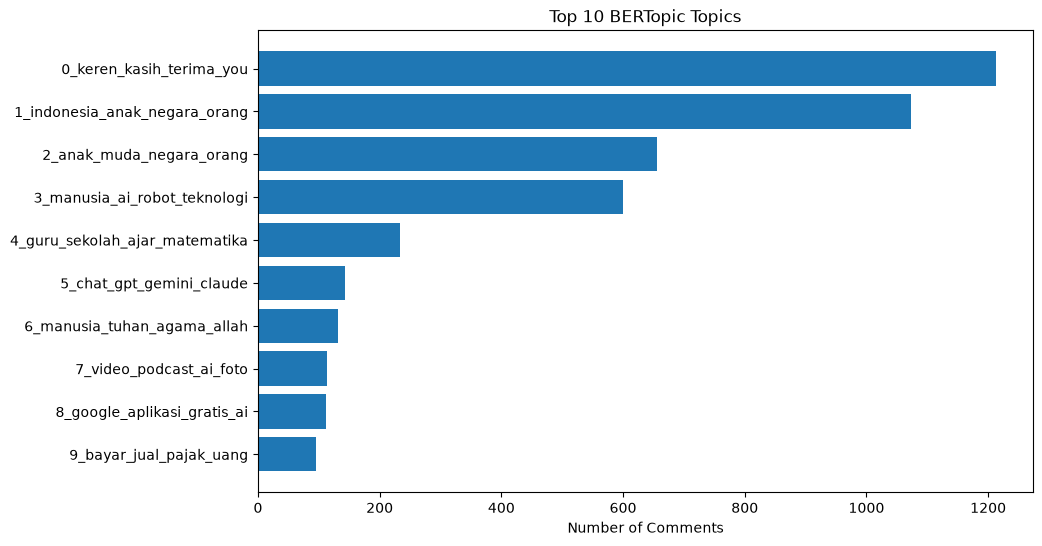

In [63]:
# ==========================================================
# TOPIC FREQUENCY
# ==========================================================

top_topics = topic_info[
    topic_info["Topic"] != -1
].head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_topics["Name"],
    top_topics["Count"]
)

plt.xlabel("Number of Comments")

plt.title("Top 10 BERTopic Topics")

plt.gca().invert_yaxis()

plt.show()

# 10. K-Means and BERTopic Comparison

K-Means digunakan untuk mengelompokkan komentar berdasarkan kemiripan, sedangkan BERTopic digunakan untuk mengekstraksi topik yang muncul dalam dataset.


In [66]:
comparison_method = pd.DataFrame({

    "Aspect":[

        "Method",

        "Output",

        "Best Configuration",

        "Evaluation",

        "Interpretability"

    ],

    "K-Means":[

        "Unsupervised Clustering",

        "3 Clusters",

        "Sentence Transformer + k=3",

        "Silhouette Score = 0.0847",

        "Persona Analysis"

    ],

    "BERTopic":[

        "Topic Modeling",

        "111 Topics",

        "Multilingual BERTopic",

        "Representative Topics",

        "Topic Keywords"

    ]

})

comparison_method

,Aspect,K-Means,BERTopic
0,Method,Unsupervised Clustering,Topic Modeling
1,Output,3 Clusters,111 Topics
2,Best Configuration,Sentence Transformer + k=3,Multilingual BERTopic
3,Evaluation,Silhouette Score = 0.0847,Representative Topics
4,Interpretability,Persona Analysis,Topic Keywords


## Discussion

Sentence Transformer menghasilkan Silhouette Score tertinggi pada konfigurasi **k = 3**. Hasil clustering digunakan untuk membentuk tiga persona utama, sedangkan BERTopic digunakan untuk memperoleh topik pembahasan yang lebih spesifik.


# 11. Conclusion

Analisis berhasil menerapkan preprocessing, TF-IDF, Sentence Transformer, K-Means, dan BERTopic pada komentar YouTube. Konfigurasi clustering terbaik menggunakan Sentence Transformer dengan **k = 3**, yang kemudian digunakan untuk persona analysis dan interpretasi topik.
